# Steam Review Sentiment — Traditional NLP vs. Transformers
**ADS-509: Applied Text Mining · University of San Diego**

Collect real product reviews from the **official Steam Reviews API** (100+ modern
games) and compare a classic **TF-IDF + Logistic Regression** baseline against a
fine-tuned **DistilBERT** transformer for binary sentiment.

Sentiment label comes from each review's *recommend / not-recommend* (`voted_up`).

## 0. Imports

In [1]:
%matplotlib inline
import os, time, urllib.request, urllib.parse, json, re
from collections import Counter
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk; from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import torch
from torch.utils.data import DataLoader
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding)
nltk.download('stopwords', quiet=True)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


True

## 1. Data collection — official Steam Reviews API
We take the current top ~100 games (SteamSpy) plus modern divisive titles
(EA SPORTS FC, Call of Duty, Overwatch 2, …) so we get **both** positive and
negative reviews, then pull recent reviews of each via the public Steam endpoint
`https://store.steampowered.com/appreviews/<appid>?json=1`.

In [2]:
HDR = {"User-Agent": "Mozilla/5.0 (academic review collection)"}
PER_TYPE = 28   # few reviews per game -> spread across MANY games for variety

SEED = {2669320:"EA SPORTS FC 25", 2195250:"EA SPORTS FC 24", 1811260:"FIFA 23",
        2357570:"Overwatch 2", 1665460:"eFootball 2024", 1517290:"Battlefield 2042",
        2344520:"Diablo IV", 1716740:"Starfield", 2054970:"Dragon's Dogma 2",
        2429640:"Throne and Liberty", 1086940:"Baldur's Gate 3", 1623730:"Palworld",
        2358720:"Black Myth: Wukong", 553850:"Helldivers 2", 2183900:"Space Marine 2",
        2767030:"Marvel Rivals", 1245620:"Elden Ring", 1091500:"Cyberpunk 2077"}

def get_top_games():
    "Merge several SteamSpy top lists for a broad, varied pool (~200+ games)."
    pool = {}
    for name in ["top100in2weeks", "top100forever", "top100owned"]:
        try:
            req = urllib.request.Request(f"https://steamspy.com/api.php?request={name}", headers=HDR)
            for a, v in json.load(urllib.request.urlopen(req, timeout=30)).items():
                pool[int(a)] = v.get("name", f"App {a}")
            time.sleep(1)
        except Exception as e:
            print(name, "unavailable:", e)
    return pool

def fetch(appid, review_type, want):
    out, cursor = [], "*"
    while len(out) < want:
        q = urllib.parse.urlencode({"json":1,"num_per_page":100,"filter":"recent","language":"english",
                                    "review_type":review_type,"purchase_type":"all","cursor":cursor})
        try:
            req = urllib.request.Request(f"https://store.steampowered.com/appreviews/{appid}?{q}", headers=HDR)
            data = json.load(urllib.request.urlopen(req, timeout=30))
        except Exception:
            break
        revs = data.get("reviews", [])
        if not revs: break
        out.extend(revs); cursor = data.get("cursor", "")
        if not cursor: break
        time.sleep(0.2)
    return out[:want]

MAX_GAMES, MIN_TS = 250, 1704067200   # MIN_TS = 2024-01-01 (keep recent reviews only)

# Reuse the already-collected file if present (fast + consistent); else scrape live.
if os.path.exists("steam_reviews.csv"):
    df = pd.read_csv("steam_reviews.csv")[["product_name","text","label"]].dropna()
    print("loaded", len(df), "reviews from steam_reviews.csv")
else:
    games = dict(list({**SEED, **get_top_games()}.items())[:MAX_GAMES])
    rows, seen = [], set()
    for appid, name in games.items():
        for rtype, label in [("positive",1), ("negative",0)]:
            for v in fetch(appid, rtype, PER_TYPE):
                rid = v.get("recommendationid")
                if rid in seen: continue
                seen.add(rid)
                if v.get("timestamp_created",0) < MIN_TS: continue
                text = (v.get("review") or "").replace("\n"," ").strip()
                if len(text) < 5: continue
                rows.append({"product_name":name, "text":text, "label":label})
    df = pd.DataFrame(rows); df.to_csv("steam_reviews.csv", index=False)
print("reviews:", len(df), "| games:", df.product_name.nunique())
df.head()

loaded 12661 reviews from steam_reviews.csv
reviews: 12661 | games: 247


,product_name,text,label
0,EA SPORTS FC 25,I think this is the FIFA/FC game I played the ...,1
1,EA SPORTS FC 25,I saw a fenomenon somebody used X to pass the ...,1
2,EA SPORTS FC 25,I ROVE FOOTBARR,1
3,EA SPORTS FC 25,messi gOAT,1
4,EA SPORTS FC 25,i did not even played an hour its my cousins,1


## 2. Balanced binary sample
Labels come from recommend (1) / not-recommend (0). Balance the two classes.

In [3]:
n = min((df.label==1).sum(), (df.label==0).sum())
df = pd.concat([df[df.label==1].sample(n, random_state=42),
                df[df.label==0].sample(n, random_state=42)]).sample(frac=1, random_state=42).reset_index(drop=True)
print("balanced:", len(df)); print(df.label.value_counts())

balanced: 12182
label
1    6091
0    6091
Name: count, dtype: int64


## 3. Exploratory data analysis

label
0    53.942702
1    29.467083
Name: len, dtype: float64


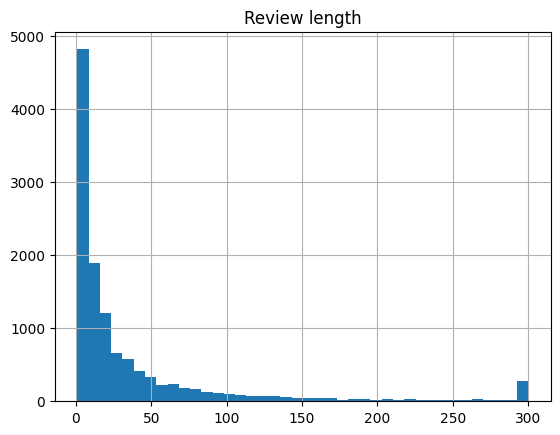

In [4]:
df["len"] = df["text"].str.split().map(len)
print(df.groupby("label")["len"].mean())
df["len"].clip(upper=300).hist(bins=40); plt.title("Review length"); plt.show()

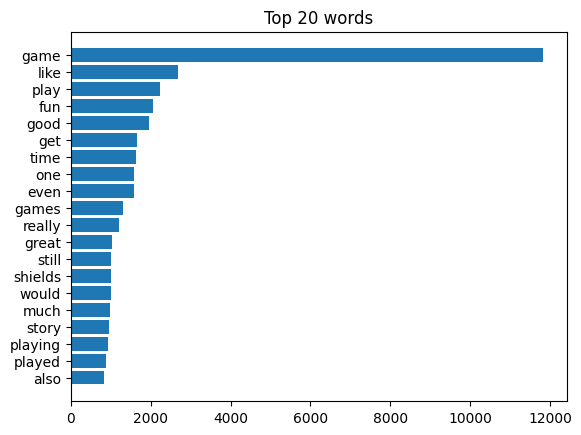

In [5]:
stop = set(stopwords.words("english"))
words = [w.lower() for w in re.findall(r"[A-Za-z']{3,}", " ".join(df["text"])) if w.lower() not in stop]
freq = Counter(words)
top = pd.DataFrame(freq.most_common(20), columns=["word","n"])
plt.barh(top["word"][::-1], top["n"][::-1]); plt.title("Top 20 words"); plt.show()

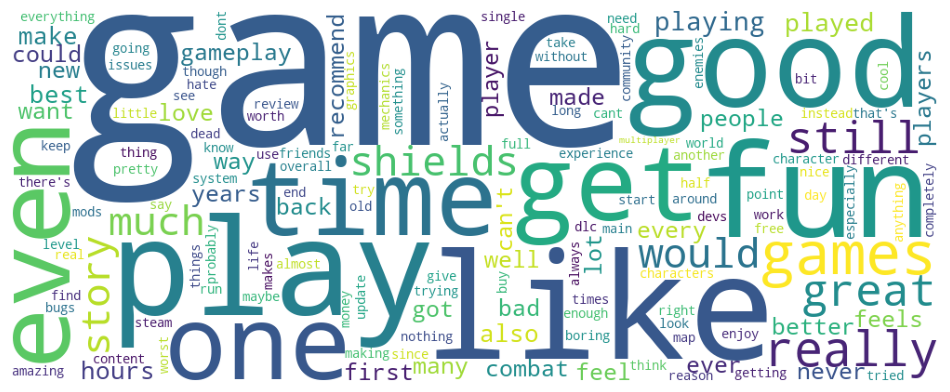

In [6]:
WordCloud(width=1000, height=400, background_color="white").generate_from_frequencies(dict(freq.most_common(150)))
plt.figure(figsize=(12,5)); plt.imshow(WordCloud(width=1000,height=400,background_color="white").generate_from_frequencies(dict(freq.most_common(150)))); plt.axis("off"); plt.show()

## 4. Baseline — TF-IDF + Logistic Regression

In [7]:
Xtr, Xte, ytr, yte = train_test_split(df["text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"])
vec = TfidfVectorizer(stop_words="english", max_features=5000)
lr = LogisticRegression(max_iter=1000).fit(vec.fit_transform(Xtr), ytr)
pred = lr.predict(vec.transform(Xte))
print("Accuracy:", round(accuracy_score(yte, pred), 4))
print(classification_report(yte, pred, target_names=["Negative","Positive"]))

Accuracy: 0.7887
              precision    recall  f1-score   support

    Negative       0.79      0.79      0.79      1219
    Positive       0.79      0.79      0.79      1218

    accuracy                           0.79      2437
   macro avg       0.79      0.79      0.79      2437
weighted avg       0.79      0.79      0.79      2437



## 5. Fine-tune DistilBERT
`distilbert-base-uncased`, 1 epoch, AdamW (lr 2e-5), batch 8, max-len 128.

Map:   0%|          | 0/9745 [00:00<?, ? examples/s]

Map:   0%|          | 0/2437 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


step 0 loss 0.6841
step 200 loss 0.7004
step 400 loss 0.3187
step 600 loss 0.2176
step 800 loss 0.1654
step 1000 loss 0.2479
step 1200 loss 0.4491
DistilBERT accuracy: 0.8605
              precision    recall  f1-score   support

    Negative       0.83      0.90      0.87      1216
    Positive       0.89      0.82      0.85      1221

    accuracy                           0.86      2437
   macro avg       0.86      0.86      0.86      2437
weighted avg       0.86      0.86      0.86      2437



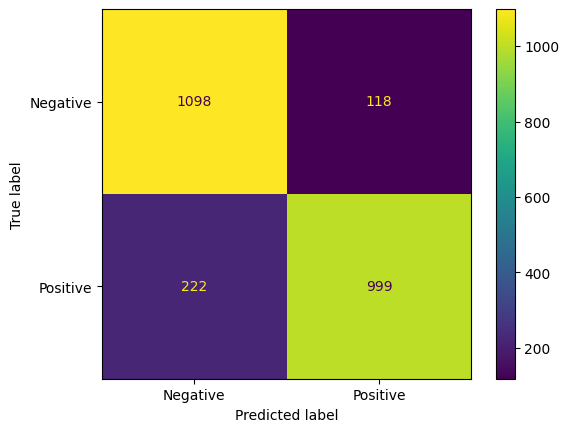

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved fine-tuned model to ./model


In [8]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
hf = Dataset.from_pandas(df[["text","label"]], preserve_index=False).train_test_split(test_size=0.2, seed=42)
tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
enc = hf.map(lambda b: tok(b["text"], truncation=True, max_length=128), batched=True, remove_columns=["text"]).rename_column("label","labels")
enc = enc.remove_columns([c for c in enc["train"].column_names if c not in ["input_ids","attention_mask","labels"]])
coll = DataCollatorWithPadding(tokenizer=tok)
tl = DataLoader(enc["train"], shuffle=True, batch_size=8, collate_fn=coll)
el = DataLoader(enc["test"], batch_size=8, collate_fn=coll)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-5)
model.train()
for step, b in enumerate(tl):
    b = {k:v.to(device) for k,v in b.items()}
    out = model(**b); out.loss.backward(); opt.step(); opt.zero_grad()
    if step % 200 == 0: print("step", step, "loss", round(out.loss.item(),4))
model.eval(); preds, labels = [], []
with torch.no_grad():
    for b in el:
        y = b["labels"]; b = {k:v.to(device) for k,v in b.items()}
        preds += torch.argmax(model(**b).logits, -1).cpu().tolist(); labels += y.tolist()
print("DistilBERT accuracy:", round(accuracy_score(labels, preds), 4))
print(classification_report(labels, preds, target_names=["Negative","Positive"]))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=["Negative","Positive"]).plot(); plt.show()

# Save the fine-tuned model so the Streamlit app can use it for live inference
model.config.id2label = {0: "NEGATIVE", 1: "POSITIVE"}
model.config.label2id = {"NEGATIVE": 0, "POSITIVE": 1}
model.save_pretrained("model"); tok.save_pretrained("model")
print("saved fine-tuned model to ./model")

## 6. Results
DistilBERT's contextual embeddings typically beat the TF-IDF + Logistic Regression
baseline by a few points on this dataset. The interactive dashboard (`app.py`)
presents these results; see the README to run it.